In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
#cell1
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import pickle
import numpy as np
import pandas as pd
from pathlib import Path

# cell1
BASE          = "/content/drive/MyDrive/RAIM_Project_v2/run_plos_only"
synthea_path  = "/content/drive/MyDrive/RAIM_Project_v2/run_05_age_med_years_med/raw/csv"
output_path   = f"{BASE}/processed"
matrices_dir  = f"{BASE}/matrices"

CHUNK_SIZE = 50_000

os.makedirs(output_path, exist_ok=True)
os.makedirs(matrices_dir, exist_ok=True)

print("Paths ready.")
print("matrices_dir:", matrices_dir)

Mounted at /content/drive
Paths ready.
matrices_dir: /content/drive/MyDrive/RAIM_Project_v2/run_plos_only/matrices


In [ ]:
# Cell 2
ENC_COLS = ['Id', 'PATIENT', 'ENCOUNTERCLASS', 'START', 'STOP']
PAT_COLS = ['Id', 'GENDER', 'RACE', 'ETHNICITY', 'BIRTHDATE']

enc_chunks = []
for chunk in pd.read_csv(f"{synthea_path}/encounters.csv", usecols=ENC_COLS, chunksize=CHUNK_SIZE):
    enc_chunks.append(chunk[chunk['ENCOUNTERCLASS'] == 'inpatient'])
encounters_df = pd.concat(enc_chunks, ignore_index=True).rename(columns={
    'Id': 'hadm_id', 'PATIENT': 'subject_id',
    'START': 'admittime', 'STOP': 'dischtime',
    'ENCOUNTERCLASS': 'admission_type',
})
del enc_chunks

inpatient_subject_ids = set(encounters_df['subject_id'])

pat_chunks = []
for chunk in pd.read_csv(f"{synthea_path}/patients.csv", usecols=PAT_COLS, chunksize=CHUNK_SIZE):
    pat_chunks.append(chunk[chunk['Id'].isin(inpatient_subject_ids)])
patients_df = pd.concat(pat_chunks, ignore_index=True).rename(columns={
    'Id': 'subject_id', 'GENDER': 'gender',
    'RACE': 'race', 'ETHNICITY': 'ethnicity', 'BIRTHDATE': 'birthdate',
})
del pat_chunks

df = encounters_df.merge(patients_df, on='subject_id', how='left')
del encounters_df, patients_df

for col in ('admittime', 'dischtime', 'birthdate'):
    df[col] = pd.to_datetime(df[col], errors='coerce').dt.tz_localize(None)

df = df.dropna(subset=['admittime', 'dischtime']).copy()
df['LOS'] = (df['dischtime'] - df['admittime']).dt.days
df['anchor_age'] = (df['admittime'] - df['birthdate']).dt.days // 365
df = df[(df['LOS'] > 0) & (df['LOS'] <= 500)].copy()

# 1990 filter
df = df[df['admittime'].dt.year >= 1990].copy()

# PLOS cohort filter — keep patients with at least one encounter > threshold
los_mean = df['LOS'].mean()
los_std  = df['LOS'].std(ddof=0)
los_threshold = los_mean + 2 * los_std
print(f"LOS mean: {los_mean:.2f}  std: {los_std:.2f}  threshold: {los_threshold:.2f}")

llos_df = df[df['LOS'] > los_threshold].copy()
cohort_subj_ids = set(llos_df['subject_id'])
df = df[df['subject_id'].isin(cohort_subj_ids)].copy()

# --- snapshot mixed cohort before the pure-PLOS-only filter narrows df further ---
mixed_los_days = df['LOS'].copy()
mixed_cohort_hadm_ids = set(df['hadm_id'])
print(f"Mixed cohort encounters: {len(df)}, patients: {df['subject_id'].nunique()}")
# -----------------------------------------------------------------------------

# ── PURE PLOS RUN: keep only patients whose EVERY encounter is > threshold ──
patient_min_los = df.groupby('subject_id')['LOS'].min()
pure_plos_patients = set(patient_min_los[patient_min_los > los_threshold].index)
df = df[df['subject_id'].isin(pure_plos_patients)].copy()
# ───────────────────────────────────────────────────────────────────────────

df = df.rename(columns={'LOS': 'target'})
cohort_hadm_ids = set(df['hadm_id'])

print(f"Pure PLOS encounters: {len(df)}")
print(f"Unique patients: {df['subject_id'].nunique()}")
print(df['target'].describe())

LOS mean: 4.69  std: 5.14  threshold: 14.96
Mixed cohort encounters: 2578, patients: 309
Pure PLOS encounters: 37
Unique patients: 36
count    37.000000
mean     23.891892
std      10.897971
min      15.000000
25%      17.000000
50%      20.000000
75%      27.000000
max      68.000000
Name: target, dtype: float64


In [ ]:
# cell 2b — rebuild the MIXED cohort in parallel, without disturbing
# the pure-PLOS `df` / `cohort_hadm_ids` that cells 3–26 already used

# df was reassigned to the pure-PLOS subset inside Cell 2. Rebuild the
# mixed-cohort frame from scratch using the same encounters/patients load,
# stopping right before the pure-PLOS narrowing step.

enc_chunks = []
for chunk in pd.read_csv(f"{synthea_path}/encounters.csv", usecols=ENC_COLS, chunksize=CHUNK_SIZE):
    enc_chunks.append(chunk[chunk['ENCOUNTERCLASS'] == 'inpatient'])
mixed_df = pd.concat(enc_chunks, ignore_index=True).rename(columns={
    'Id': 'hadm_id', 'PATIENT': 'subject_id',
    'START': 'admittime', 'STOP': 'dischtime',
    'ENCOUNTERCLASS': 'admission_type',
})
del enc_chunks

inpatient_subject_ids_mixed = set(mixed_df['subject_id'])

pat_chunks = []
for chunk in pd.read_csv(f"{synthea_path}/patients.csv", usecols=PAT_COLS, chunksize=CHUNK_SIZE):
    pat_chunks.append(chunk[chunk['Id'].isin(inpatient_subject_ids_mixed)])
mixed_pat_df = pd.concat(pat_chunks, ignore_index=True).rename(columns={
    'Id': 'subject_id', 'GENDER': 'gender',
    'RACE': 'race', 'ETHNICITY': 'ethnicity', 'BIRTHDATE': 'birthdate',
})
del pat_chunks

mixed_df = mixed_df.merge(mixed_pat_df, on='subject_id', how='left')
del mixed_pat_df

for col in ('admittime', 'dischtime', 'birthdate'):
    mixed_df[col] = pd.to_datetime(mixed_df[col], errors='coerce').dt.tz_localize(None)

mixed_df = mixed_df.dropna(subset=['admittime', 'dischtime']).copy()
mixed_df['LOS'] = (mixed_df['dischtime'] - mixed_df['admittime']).dt.days
mixed_df['anchor_age'] = (mixed_df['admittime'] - mixed_df['birthdate']).dt.days // 365
mixed_df = mixed_df[(mixed_df['LOS'] > 0) & (mixed_df['LOS'] <= 500)].copy()
mixed_df = mixed_df[mixed_df['admittime'].dt.year >= 1990].copy()

# same threshold already computed in Cell 2 (los_mean, los_std, los_threshold)
llos_df_mixed = mixed_df[mixed_df['LOS'] > los_threshold].copy()
mixed_cohort_subj_ids = set(llos_df_mixed['subject_id'])
mixed_df = mixed_df[mixed_df['subject_id'].isin(mixed_cohort_subj_ids)].copy()
mixed_df = mixed_df.rename(columns={'LOS': 'target'})

mixed_cohort_hadm_ids = set(mixed_df['hadm_id'])  # overwrite with the actual full set, matches Cell 3/8's usage

print(f"Mixed cohort encounters: {len(mixed_df)}, patients: {mixed_df['subject_id'].nunique()}")
# should print 2,578 encounters / 309 patients to match Table 3 / Section 5.1

Mixed cohort encounters: 2578, patients: 309


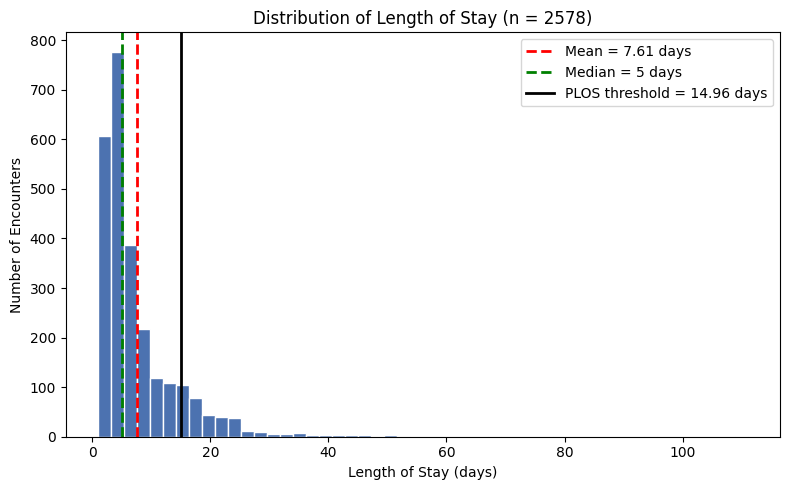

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(mixed_los_days, bins=50, color='#4C72B0', edgecolor='white')
ax.axvline(mixed_los_days.mean(), color='red', linestyle='--', linewidth=2,
           label=f"Mean = {mixed_los_days.mean():.2f} days")
ax.axvline(mixed_los_days.median(), color='green', linestyle='--', linewidth=2,
           label=f"Median = {mixed_los_days.median():.0f} days")
ax.axvline(los_threshold, color='black', linewidth=2,
           label=f"PLOS threshold = {los_threshold:.2f} days")
ax.set_xlabel("Length of Stay (days)")
ax.set_ylabel("Number of Encounters")
ax.set_title(f"Distribution of Length of Stay (n = {len(mixed_los_days)})")
ax.legend()
plt.tight_layout()
plt.savefig(f"{output_path}/los_distribution.png", dpi=300)
plt.show()

In [ ]:
# cell 3
OBS_COLS = ['PATIENT', 'ENCOUNTER', 'DATE', 'DESCRIPTION', 'VALUE', 'UNITS']

obs_chunks = []
for chunk in pd.read_csv(f"{synthea_path}/observations.csv", usecols=OBS_COLS, chunksize=CHUNK_SIZE):
    obs_chunks.append(chunk[chunk['ENCOUNTER'].isin(cohort_hadm_ids)])
observations_df = pd.concat(obs_chunks, ignore_index=True).rename(columns={
    'PATIENT': 'subject_id', 'ENCOUNTER': 'hadm_id',
    'DATE': 'obs_date', 'DESCRIPTION': 'obs_description',
    'VALUE': 'obs_value', 'UNITS': 'obs_units',
})
del obs_chunks

observations_df['obs_date'] = pd.to_datetime(
    observations_df['obs_date'], errors='coerce'
).dt.tz_localize(None)

print(f"Observations loaded: {len(observations_df)}")

Observations loaded: 7047


In [ ]:
# mixed-cohort observations pull, parallel to cell 3, does not replace observations_df
obs_chunks_mixed = []
for chunk in pd.read_csv(f"{synthea_path}/observations.csv", usecols=OBS_COLS, chunksize=CHUNK_SIZE):
    obs_chunks_mixed.append(chunk[chunk['ENCOUNTER'].isin(mixed_cohort_hadm_ids)])
observations_df_mixed = pd.concat(obs_chunks_mixed, ignore_index=True).rename(columns={
    'PATIENT': 'subject_id', 'ENCOUNTER': 'hadm_id',
    'DATE': 'obs_date', 'DESCRIPTION': 'obs_description',
    'VALUE': 'obs_value', 'UNITS': 'obs_units',
})
del obs_chunks_mixed
print(f"Mixed cohort observations loaded: {len(observations_df_mixed)}")

Mixed cohort observations loaded: 100518


In [ ]:
# cell 4 - vital snapshot into static (replaces 12x5 matrix)
VITAL_CHANNELS = {
    'Heart rate':               'hr',
    'Systolic Blood Pressure':  'sbp',
    'Diastolic Blood Pressure': 'dbp',
    'Respiratory rate':         'rr',
    'Body Weight':              'weight',
}
CHANNELS = ['hr', 'sbp', 'dbp', 'rr', 'weight']

obs_vitals = observations_df[
    observations_df['obs_description'].isin(VITAL_CHANNELS)
].copy()
obs_vitals['channel'] = obs_vitals['obs_description'].map(VITAL_CHANNELS)
obs_vitals['obs_value'] = pd.to_numeric(obs_vitals['obs_value'], errors='coerce')

# Take mean per encounter per channel (handles rare cases with multiple readings)
vital_snapshot = (
    obs_vitals.groupby(['hadm_id', 'channel'])['obs_value']
    .mean().unstack(fill_value=np.nan)
)
vital_snapshot.columns = [f'vital_{c}' for c in vital_snapshot.columns]
vital_snapshot = vital_snapshot.reindex(columns=[f'vital_{c}' for c in CHANNELS])

print(f"Vital snapshots available: {len(vital_snapshot)} / {len(df)} encounters")
print(f"Coverage per channel:\n{vital_snapshot.notna().mean()}")

Vital snapshots available: 10 / 37 encounters
Coverage per channel:
vital_hr        0.0
vital_sbp       0.0
vital_dbp       0.0
vital_rr        0.0
vital_weight    1.0
dtype: float64


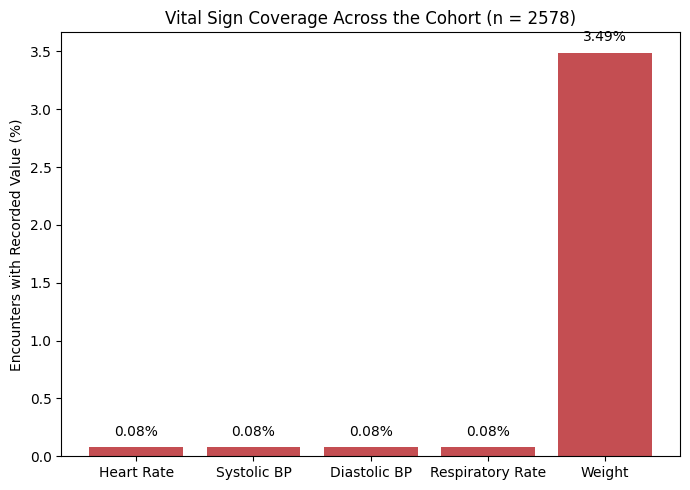

In [ ]:
obs_vitals_mixed = observations_df_mixed[
    observations_df_mixed['obs_description'].isin(VITAL_CHANNELS)
].copy()
obs_vitals_mixed['channel'] = obs_vitals_mixed['obs_description'].map(VITAL_CHANNELS)
obs_vitals_mixed['obs_value'] = pd.to_numeric(obs_vitals_mixed['obs_value'], errors='coerce')

vital_snapshot_mixed = (
    obs_vitals_mixed.groupby(['hadm_id', 'channel'])['obs_value']
    .mean().unstack(fill_value=np.nan)
)
vital_snapshot_mixed.columns = [f'vital_{c}' for c in vital_snapshot_mixed.columns]
vital_snapshot_mixed = vital_snapshot_mixed.reindex(
    columns=[f'vital_{c}' for c in CHANNELS], index=list(mixed_cohort_hadm_ids)
)

coverage_pct = vital_snapshot_mixed.notna().mean() * 100
labels = ['Heart Rate', 'Systolic BP', 'Diastolic BP', 'Respiratory Rate', 'Weight']

fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(labels, coverage_pct.values, color='#C44E52')
ax.set_ylabel("Encounters with Recorded Value (%)")
ax.set_title(f"Vital Sign Coverage Across the Cohort (n = {len(mixed_cohort_hadm_ids)})")
for bar, pct in zip(bars, coverage_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, pct + 0.1, f"{pct:.2f}%", ha='center')
plt.tight_layout()
plt.savefig(f"{output_path}/vitals_coverage.png", dpi=300)
plt.show()

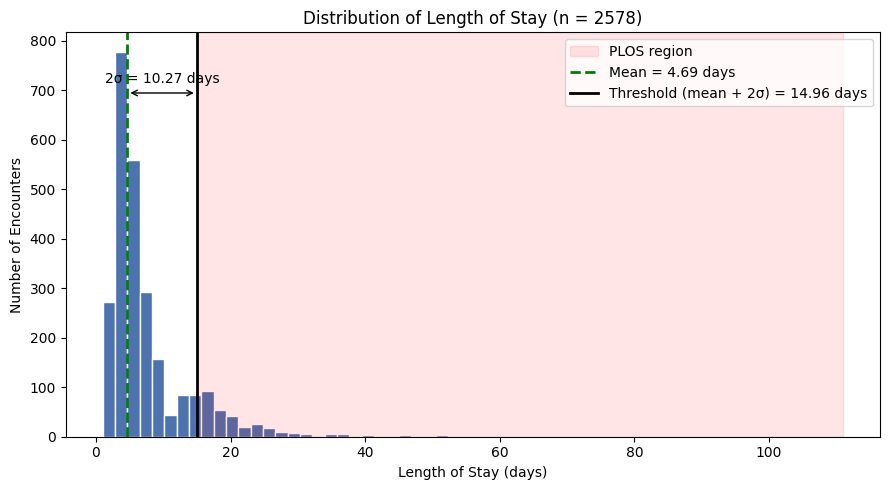

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9,5))
ax.hist(mixed_los_days, bins=60, color='#4C72B0', edgecolor='white')

# shade the PLOS region
ax.axvspan(los_threshold, mixed_los_days.max(), color='red', alpha=0.1, label='PLOS region')

ax.axvline(los_mean, color='green', linestyle='--', linewidth=2,
           label=f"Mean = {los_mean:.2f} days")
ax.axvline(los_threshold, color='black', linewidth=2,
           label=f"Threshold (mean + 2\u03c3) = {los_threshold:.2f} days")

# annotate the 2-std distance from mean to threshold
y_max = ax.get_ylim()[1]
arrow_y = y_max * 0.85
ax.annotate('', xy=(los_threshold, arrow_y), xytext=(los_mean, arrow_y),
            arrowprops=dict(arrowstyle='<->', color='black'))
ax.text((los_mean + los_threshold) / 2, arrow_y * 1.03,
        f"2\u03c3 = {2*los_std:.2f} days", ha='center', fontsize=10)

ax.set_xlabel("Length of Stay (days)")
ax.set_ylabel("Number of Encounters")
ax.set_title(f"Distribution of Length of Stay (n = {len(mixed_los_days)})")
ax.legend()
plt.tight_layout()
plt.savefig(f"{output_path}/los_distribution_plos.png", dpi=300)
plt.show()

In [ ]:
# cell 5 - encounter-level lab/med activity flags (12-hour windowing removed)
LAB_SKIP = {
    'Heart rate', 'Systolic Blood Pressure', 'Diastolic Blood Pressure',
    'Respiratory rate', 'Body Weight', 'Body Height',
    'Body mass index (BMI) [Ratio]',
    'Pain severity - 0-10 verbal numeric rating [Score] - Reported',
    'DALY', 'QOLS', 'QALY'
}

# Compute hours from admit for all observations (still needed to bound to encounter window)
obs_with_admit = observations_df.merge(
    df[['hadm_id', 'admittime', 'dischtime']], on='hadm_id', how='inner'
)
obs_with_admit['hours_from_admit'] = (
    (obs_with_admit['obs_date'] - obs_with_admit['admittime'])
    .dt.total_seconds() / 3600
)
obs_with_admit = obs_with_admit[
    (obs_with_admit['hours_from_admit'] >= 0) &
    (obs_with_admit['obs_date'] <= obs_with_admit['dischtime'])
].copy()

# Lab activity per encounter (any non-vital observation during the stay)
labs_in_enc = obs_with_admit[
    ~obs_with_admit['obs_description'].isin(LAB_SKIP)
].copy()
lab_flags = labs_in_enc[['hadm_id']].drop_duplicates()

# Med activity per encounter
med_chunks = []
for chunk in pd.read_csv(f"{synthea_path}/medications.csv",
                          usecols=['START', 'ENCOUNTER'], chunksize=CHUNK_SIZE):
    chunk = chunk[chunk['ENCOUNTER'].isin(cohort_hadm_ids)].copy()
    med_chunks.append(chunk)
meds_df = pd.concat(med_chunks, ignore_index=True)
meds_df.columns = ['med_start', 'hadm_id']
meds_df['med_start'] = pd.to_datetime(meds_df['med_start'], errors='coerce').dt.tz_localize(None)
del med_chunks

meds_in_enc = meds_df.merge(df[['hadm_id', 'admittime', 'dischtime']], on='hadm_id', how='inner')
meds_in_enc = meds_in_enc[
    (meds_in_enc['med_start'] >= meds_in_enc['admittime']) &
    (meds_in_enc['med_start'] <= meds_in_enc['dischtime'])
].copy()
med_flags = meds_in_enc[['hadm_id']].drop_duplicates()

print(f"Lab events in encounter window: {len(labs_in_enc)}")
print(f"Med events in encounter window: {len(meds_in_enc)}")

Lab events in encounter window: 6849
Med events in encounter window: 371


In [ ]:
# cell 5b - Medication Word2Vec (per-encounter ordered sequences)
!pip install -q gensim
import re
from gensim.models import Word2Vec

# --- Drug name cleaning (adapted from med_freq.py for Synthea DESCRIPTION column) ---

FORM_KEYWORDS = [
    "TABLET", "CAPSULE", "INJECTION", "ORAL SOLUTION", "SOLUTION", "SUSPENSION",
    "SYRINGE", "VIAL", "PATCH", "BAG", "SPRAY", "CREAM", "OINTMENT", "SUPPOSITORY",
    "DROPPER", "DISKUS", "DEVICE", "LOZENGE", "TUBE", "ELIXIR", "LIQUID", "NEBULIZER",
    "ORAL", "POWDER", "GRANULES", "CONCENTRATE", "PREFILLED",
]

CORRECTIONS = {
    "ABACAV": "ABACAVIR",
    "POTASSIUM CHL": "POTASSIUM CHLORIDE",
}

def clean_drug_name(desc):
    if not isinstance(desc, str):
        return "UNKNOWN"
    desc = desc.upper().strip()
    desc = re.sub(r'\*(NF|NON-FORMULARY|OB|DC)\*\s*', '', desc)
    desc = re.sub(r'\*NON-FORMULARY\*', '', desc)
    desc = re.sub(r'\s*\(.*?\)', '', desc)
    desc = re.sub(r'\s*\d+(\.\d+)?\s*%$', '', desc)
    for form in FORM_KEYWORDS:
        desc = desc.replace(form, '')
    desc = desc.strip()
    for wrong, right in CORRECTIONS.items():
        desc = desc.replace(wrong, right)
    return desc.strip() if desc.strip() else "UNKNOWN"

def extract_dose_string(desc):
    if not isinstance(desc, str):
        return "UNKNOWN"
    desc_lower = desc.lower().strip()
    match = re.search(
        r'(\d+\.?\d*)\s*(mg|mcg|g|gram|grams|ml|mL|iu|units|mEq|%)',
        desc_lower, re.IGNORECASE
    )
    if match:
        number = match.group(1)
        unit = match.group(2).replace("grams", "g").replace("gram", "g")
        return f"{number}{unit}".upper()
    match_frac = re.search(
        r'(\d+\.?\d*)\s*/\s*(\d+\.?\d*)\s*(mg|mcg|ml|mL|units)',
        desc_lower, re.IGNORECASE
    )
    if match_frac:
        return f"{match_frac.group(1)}/{match_frac.group(2)}{match_frac.group(3)}".upper()
    return "UNKNOWN"

def build_med_token(desc):
    name = clean_drug_name(desc)
    # strip numeric dose info from name since we're extracting it separately
    name = re.sub(r'\d+\.?\d*\s*(MG|MCG|G|ML|IU|MEQ|UNITS)', '', name).strip()
    name = re.sub(r'\s+', '_', name).strip('_')
    dose = extract_dose_string(desc)
    return f"{name}_{dose}" if name and name != "UNKNOWN" else "UNKNOWN"

# --- Load full medication rows for cohort ---
med_seq_chunks = []
for chunk in pd.read_csv(
    f"{synthea_path}/medications.csv",
    usecols=['START', 'STOP', 'ENCOUNTER', 'PATIENT', 'DESCRIPTION'],
    chunksize=CHUNK_SIZE
):
    med_seq_chunks.append(chunk[chunk['ENCOUNTER'].isin(cohort_hadm_ids)])
med_seq_df = pd.concat(med_seq_chunks, ignore_index=True).rename(columns={
    'ENCOUNTER': 'hadm_id',
    'PATIENT':   'subject_id',
    'START':     'med_start',
    'DESCRIPTION': 'description',
})
del med_seq_chunks

med_seq_df['med_start'] = pd.to_datetime(med_seq_df['med_start'], errors='coerce').dt.tz_localize(None)
med_seq_df['med_token'] = med_seq_df['description'].apply(build_med_token)

# Drop unknowns
med_seq_df = med_seq_df[med_seq_df['med_token'] != 'UNKNOWN'].copy()

print(f"Medication rows loaded: {len(med_seq_df)}")
print(f"Unique med tokens: {med_seq_df['med_token'].nunique()}")
print(f"Sample tokens: {med_seq_df['med_token'].value_counts().head(10).index.tolist()}")

# --- Build per-encounter ordered token sequences ---
# Sort by hadm_id then med_start (timestamp order per encounter)
med_seq_df = med_seq_df.sort_values(['hadm_id', 'med_start'])

enc_med_sequences = (
    med_seq_df.groupby('hadm_id')['med_token']
    .apply(list)
    .to_dict()
)  # hadm_id -> [token1, token2, ...] in time order

# --- Also build per-patient sequences for W2V training ---
# Join subject_id, sort by med_start across all encounters per patient
med_seq_df = med_seq_df.merge(df[['hadm_id', 'admittime']], on='hadm_id', how='left')
med_seq_df = med_seq_df.sort_values(['subject_id', 'med_start'])

patient_med_sequences = (
    med_seq_df.groupby('subject_id')['med_token']
    .apply(list)
    .tolist()
)
patient_med_sequences = [s for s in patient_med_sequences if len(s) > 0]

# --- Train Word2Vec ---
med_w2v = Word2Vec(
    sentences=patient_med_sequences,
    vector_size=128,
    window=5,
    min_count=1,
    sg=1,
    epochs=10,
    seed=105,
    workers=4,
)
med_w2v.save(f"{matrices_dir}/word2vec_medications.model")

print(f"Medication W2V trained: {len(patient_med_sequences)} patient sequences, vocab={len(med_w2v.wv)}")

Medication rows loaded: 371
Unique med tokens: 2
Sample tokens: ['FUROSEMIDE_/ML_10ML', 'MEPERIDINE_HYDROCHLORIDE_50MG']
Medication W2V trained: 11 patient sequences, vocab=2


In [ ]:
# Cell 6 - Parse note files, extract section closest to each encounter's admittime
import os
import re
import pickle
from datetime import datetime, timedelta

# Cell 6
notes_dir = "/content/drive/MyDrive/RAIM_Project_v2/run_05_age_med_years_med/raw/notes"
note_files = os.listdir(notes_dir)
subject_to_notefile = {}
for fname in note_files:
    uuid = fname.replace('.txt', '').split('_')[-1]
    subject_to_notefile[uuid] = os.path.join(notes_dir, fname)

print(f"Note files indexed: {len(subject_to_notefile)}")

DATE_PATTERN = re.compile(r'^\d{4}-\d{2}-\d{2}', re.MULTILINE)

def parse_note_sections(note_text):
    matches = list(DATE_PATTERN.finditer(note_text))
    sections = []
    for i, match in enumerate(matches):
        date_str = match.group()
        start = match.start()
        end = matches[i+1].start() if i+1 < len(matches) else len(note_text)
        chunk = note_text[start:end].strip()
        try:
            date = datetime.strptime(date_str, '%Y-%m-%d')
            sections.append((date, chunk))
        except:
            continue
    return sections

def assign_sections_for_patient(sections, encounters, tolerance_days=3):
    candidates = []
    for e_idx, (hadm_id, admittime) in enumerate(encounters):
        admit_dt = pd.Timestamp(admittime).to_pydatetime().replace(tzinfo=None)
        for s_idx, (sec_date, sec_text) in enumerate(sections):
            delta = abs(sec_date - admit_dt)
            if delta <= timedelta(days=tolerance_days):
                candidates.append((delta, e_idx, s_idx))

    candidates.sort(key=lambda x: x[0])
    used_section_idxs = set()
    assigned_encounters = set()
    assignments = {}

    for delta, e_idx, s_idx in candidates:
        if e_idx in assigned_encounters or s_idx in used_section_idxs:
            continue
        assignments[encounters[e_idx][0]] = sections[s_idx][1]
        used_section_idxs.add(s_idx)
        assigned_encounters.add(e_idx)

    return assignments

encounter_notes = {}
missing_file = 0
no_match = 0

for subject_id, group in df.groupby('subject_id'):
    uuid = subject_id
    if uuid not in subject_to_notefile:
        missing_file += len(group)
        continue
    with open(subject_to_notefile[uuid], 'r', encoding='utf-8', errors='ignore') as f:
        note_text = f.read()
    sections = parse_note_sections(note_text)
    encounters = list(zip(group['hadm_id'], group['admittime']))
    assignments = assign_sections_for_patient(sections, encounters)
    for hadm_id, text in assignments.items():
        encounter_notes[hadm_id] = text
    no_match += len(encounters) - len(assignments)

print(f"Encounter notes extracted: {len(encounter_notes)} / {len(df)}")
print(f"Missing note file: {missing_file}")
print(f"No matching section found: {no_match}")

with open(f"{matrices_dir}/encounter_notes.pkl", 'wb') as f:
    pickle.dump(encounter_notes, f)
print("Saved encounter_notes.pkl")

Note files indexed: 11418
Encounter notes extracted: 37 / 37
Missing note file: 0
No matching section found: 0
Saved encounter_notes.pkl


In [ ]:
# Cell 7 - inspect raw note format before writing section parser
sample_hadm = next(iter(encounter_notes))
print(encounter_notes[sample_hadm][:3000])

1995-09-21

# Chief Complaint
- Hunger


# History of Present Illness
Grant908 is a 45 year-old nonhispanic white male. Patient has a history of limited social contact (finding).

# Social History
Patient is married. Patient quit smoking at age 17.
 Patient identifies as heterosexual.

Patient comes from a middle socioeconomic background.
 Patient has completed some college courses.
Patient currently has Medicaid.

# Allergies
No Known Allergies.

# Medications
No Active Medications.

# Assessment and Plan
Patient is presenting with history of renal transplant (situation). 


## Plan


In [ ]:
# Cell 8 - Stage 2a: keep only clinically relevant sections, drop Social History
import re

KEEP_SECTIONS = {
    'hpi': re.compile(r'\b(history of present illness|hpi)\b', re.IGNORECASE),
    'allergies': re.compile(r'\ballerg(y|ies)\b', re.IGNORECASE),
    'medications': re.compile(r'\b(medications?|meds)\b', re.IGNORECASE),
    'assessment_plan': re.compile(r'\b(assessment( and | & |/)?plan|assessment|plan)\b', re.IGNORECASE),
    'radiology': re.compile(r'\b(radiology|imaging)\b', re.IGNORECASE),
    'nursing': re.compile(r'\bnursing\b', re.IGNORECASE),
}
DROP_SECTIONS = {
    'social_history': re.compile(r'\bsocial history\b', re.IGNORECASE),
}

# was: HEADER_PATTERN = re.compile(r'^([A-Za-z][A-Za-z /&]{2,60}):\s*$', re.MULTILINE)
HEADER_PATTERN = re.compile(r'^#{1,3}\s*(.+?)\s*$', re.MULTILINE)

def split_into_sections(note_text):
    """Returns list of (header_text, body_text)."""
    matches = list(HEADER_PATTERN.finditer(note_text))
    sections = []
    for i, m in enumerate(matches):
        header = m.group(1).strip()
        start = m.end()
        end = matches[i+1].start() if i+1 < len(matches) else len(note_text)
        body = note_text[start:end].strip()
        sections.append((header, body))
    return sections

def classify_header(header):
    for name, pattern in KEEP_SECTIONS.items():
        if pattern.search(header):
            return name
    for name, pattern in DROP_SECTIONS.items():
        if pattern.search(header):
            return None  # explicitly dropped
    return None  # anything unrecognized is dropped too

encounter_notes_filtered = {}
kept_section_counts = {k: 0 for k in KEEP_SECTIONS}
no_sections_found = 0

for hadm_id, raw_text in encounter_notes.items():
    sections = split_into_sections(raw_text)
    if not sections:
        no_sections_found += 1
        continue
    kept = {}
    for header, body in sections:
        tag = classify_header(header)
        if tag is not None and body:
            kept[tag] = kept.get(tag, '') + ' ' + body
            kept_section_counts[tag] += 1
    if kept:
        encounter_notes_filtered[hadm_id] = kept  # dict: section_name -> text

print(f"Encounters with filtered sections: {len(encounter_notes_filtered)} / {len(encounter_notes)}")
print(f"No headers matched at all: {no_sections_found}")
print("Section coverage:", kept_section_counts)

with open(f"{matrices_dir}/encounter_notes_filtered.pkl", 'wb') as f:
    pickle.dump(encounter_notes_filtered, f)
print("Saved encounter_notes_filtered.pkl")

Encounters with filtered sections: 37 / 37
No headers matched at all: 0
Section coverage: {'hpi': 37, 'allergies': 37, 'medications': 37, 'assessment_plan': 36, 'radiology': 0, 'nursing': 0}
Saved encounter_notes_filtered.pkl


In [ ]:
# Cell 9 - Stage 2b: strip pronouns from HPI section only, before scispaCy normalization
PRONOUN_PATTERN = re.compile(
    r'\b(he|she|him|her|his|hers|himself|herself|they|them|their|theirs|themselves)\b',
    re.IGNORECASE
)

for hadm_id, sections in encounter_notes_filtered.items():
    if 'hpi' in sections:
        sections['hpi'] = PRONOUN_PATTERN.sub('', sections['hpi'])
        sections['hpi'] = re.sub(r'\s+', ' ', sections['hpi']).strip()

print("Pronoun removal applied to HPI sections.")

Pronoun removal applied to HPI sections.


In [ ]:
!pip install spacy==3.7.4
!pip install scispacy==0.5.4 --no-deps
!pip install conllu nmslib-metabrainz  # scispacy's other real deps, since --no-deps skips all of them
!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz

  Using cached https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz (14.8 MB)
  Preparing metadata (setup.py) ... done


In [ ]:
import spacy
nlp = spacy.load("en_core_sci_sm")
doc = nlp("Patient started on lisinopril 10mg daily for hypertension.")
print([(ent.text, ent.label_) for ent in doc.ents])

/usr/local/lib/python3.12/dist-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


[('Patient', 'ENTITY'), ('lisinopril', 'ENTITY'), ('daily', 'ENTITY'), ('hypertension', 'ENTITY')]


In [ ]:
# Cell 10 : abbreviation expansion + normalization via scispaCy
import spacy
from scispacy.abbreviation import AbbreviationDetector
import pickle

nlp = spacy.load("en_core_sci_sm")
nlp.add_pipe("abbreviation_detector")

def expand_abbreviations(text):
    if not text:
        return text
    doc = nlp(text)
    expanded = text
    for abrv in sorted(doc._.abbreviations, key=lambda a: len(a.text), reverse=True):
        long_form = str(abrv._.long_form)
        expanded = expanded.replace(abrv.text, long_form)
    return expanded

encounter_notes_normalized = {}

for hadm_id, sections in encounter_notes_filtered.items():
    normalized_sections = {}
    for section_name, text in sections.items():
        normalized_sections[section_name] = expand_abbreviations(text)
    encounter_notes_normalized[hadm_id] = normalized_sections

print(f"Normalized {len(encounter_notes_normalized)} encounters.")

with open(f"{matrices_dir}/encounter_notes_normalized.pkl", 'wb') as f:
    pickle.dump(encounter_notes_normalized, f)
print("Saved encounter_notes_normalized.pkl")

/usr/local/lib/python3.12/dist-packages/scispacy/abbreviation.py:248: UserWarning: [W036] The component 'matcher' does not have any patterns defined.
  global_matches = self.global_matcher(doc)


Normalized 37 encounters.
Saved encounter_notes_normalized.pkl


In [ ]:
# Cell 11 : extended tokenization producing final token sequences per encounter
PHI_PATTERNS = [
    (re.compile(r'\b\d{1,2}/\d{1,2}/\d{2,4}\b'), ' DATE '),
    (re.compile(r'\b\d{3}-\d{3}-\d{4}\b'), ' PHONE '),
    (re.compile(r'\b\d{3}-\d{2}-\d{4}\b'), ' SSN '),
    (re.compile(r'\b(mr|mrs|ms|dr)\.?\s+[A-Z][a-z]+\b', re.IGNORECASE), ' NAME '),
]

AGE_PATTERN = re.compile(r'\b(\d{1,3})\s*(?:years?[\s-]*old|y\.?o\.?|yo)\b', re.IGNORECASE)

def bin_age(match):
    age = int(match.group(1))
    if age < 0 or age > 120:
        return match.group(0)
    lower = (age // 10) * 10
    return f'AGE_{lower}_{lower+9}'

LAB_HIGH_PATTERN = re.compile(r'\b\d+(\.\d+)?\s*\(?H\)?\b')
LAB_LOW_PATTERN  = re.compile(r'\b\d+(\.\d+)?\s*\(?L\)?\b')

# Terms to protect from caps-collapsing / stripping even if short or all-caps
# (allergy substances commonly appear as short caps tokens, e.g. "PCN", "NKDA")
ALLERGY_PROTECT = {'nkda', 'pcn', 'asa', 'nsaid', 'sulfa'}

def extended_tokenize(text, section_name):
    if not text:
        return []
    for pattern, repl in PHI_PATTERNS:
        text = pattern.sub(repl, text)
    text = AGE_PATTERN.sub(bin_age, text)
    text = LAB_HIGH_PATTERN.sub(' LAB_HIGH ', text)
    text = LAB_LOW_PATTERN.sub(' LAB_LOW ', text)

    tokens = []
    for raw_tok in text.split():
        tok = raw_tok.strip('.,;:()[]{}')
        if not tok:
            continue
        low = tok.lower()
        # caps collapsing: an all-caps word becomes lowercase unless it's a
        # protected allergy/abbreviation token or one of our injected tags
        if tok.isupper() and low not in ALLERGY_PROTECT and tok not in ('DATE', 'PHONE', 'SSN', 'NAME', 'LAB_HIGH', 'LAB_LOW'):
            tok = low
        if section_name == 'allergies' and low in ALLERGY_PROTECT:
            tokens.append(low)
            continue
        if len(tok) > 2 or tok in ('DATE', 'PHONE', 'SSN', 'NAME', 'LAB_HIGH', 'LAB_LOW') or low in ALLERGY_PROTECT:
            tokens.append(tok if tok.isupper() else tok.lower())
    return tokens

encounter_notes_tokens = {}
for hadm_id, sections in encounter_notes_normalized.items():
    all_tokens = []
    for section_name, text in sections.items():
        all_tokens.extend(extended_tokenize(text, section_name))
    if all_tokens:
        encounter_notes_tokens[hadm_id] = all_tokens

print(f"Tokenized {len(encounter_notes_tokens)} encounters.")
with open(f"{matrices_dir}/encounter_notes_tokens.pkl", 'wb') as f:
    pickle.dump(encounter_notes_tokens, f)
print("Saved encounter_notes_tokens.pkl")

Tokenized 37 encounters.
Saved encounter_notes_tokens.pkl


In [ ]:
# Cell 11b  : extended tokenization producing final token sequences per encounter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

PHI_PATTERNS = [
    (re.compile(r'\b\d{1,2}/\d{1,2}/\d{2,4}\b'), ' DATE '),
    (re.compile(r'\b\d{3}-\d{3}-\d{4}\b'), ' PHONE '),
    (re.compile(r'\b\d{3}-\d{2}-\d{4}\b'), ' SSN '),
    (re.compile(r'\b(mr|mrs|ms|dr)\.?\s+[A-Z][a-z]+\b', re.IGNORECASE), ' NAME '),
]

AGE_PATTERN = re.compile(r'\b(\d{1,3})\s*(?:years?[\s-]*old|y\.?o\.?|yo)\b', re.IGNORECASE)

def bin_age(match):
    age = int(match.group(1))
    if age < 0 or age > 120:
        return match.group(0)
    lower = (age // 10) * 10
    return f'AGE_{lower}_{lower+9}'

LAB_HIGH_PATTERN = re.compile(r'\b\d+(\.\d+)?\s*\(?H\)?\b')
LAB_LOW_PATTERN  = re.compile(r'\b\d+(\.\d+)?\s*\(?L\)?\b')

# Terms to protect from caps-collapsing / stripping even if short or all-caps
# (allergy substances commonly appear as short caps tokens, e.g. "PCN", "NKDA")
ALLERGY_PROTECT = {'nkda', 'pcn', 'asa', 'nsaid', 'sulfa'}

# Injected tags that must never be dropped as stopwords
PROTECTED_TAGS = {'date', 'phone', 'ssn', 'name', 'lab_high', 'lab_low'}

# Synthea boilerplate/template words that aren't in NLTK's stopword list but
# dominate note tokens without carrying clinical meaning (see notes-token EDA:
# "were"/"conducted"/"hearing"/"examinations"/"employment" etc. were the top tokens)
SYNTHEA_TEMPLATE_STOPWORDS = {
    'were', 'was', 'conducted', 'hearing', 'examinations', 'examination',
    'employment', 'reconciliations', 'reconciliation', 'findings', 'noted',
    'reviewed', 'discussed', 'performed', 'assessment', 'plan', 'presents',
}

STOPWORDS = (set(stopwords.words('english')) | SYNTHEA_TEMPLATE_STOPWORDS) - ALLERGY_PROTECT - PROTECTED_TAGS

def extended_tokenize(text, section_name):
    if not text:
        return []
    for pattern, repl in PHI_PATTERNS:
        text = pattern.sub(repl, text)
    text = AGE_PATTERN.sub(bin_age, text)
    text = LAB_HIGH_PATTERN.sub(' LAB_HIGH ', text)
    text = LAB_LOW_PATTERN.sub(' LAB_LOW ', text)

    tokens = []
    for raw_tok in text.split():
        tok = raw_tok.strip('.,;:()[]{}')
        if not tok:
            continue
        low = tok.lower()
        # caps collapsing: an all-caps word becomes lowercase unless it's a
        # protected allergy/abbreviation token or one of our injected tags
        if tok.isupper() and low not in ALLERGY_PROTECT and tok not in ('DATE', 'PHONE', 'SSN', 'NAME', 'LAB_HIGH', 'LAB_LOW'):
            tok = low
        if section_name == 'allergies' and low in ALLERGY_PROTECT:
            tokens.append(low)
            continue
        # stopword filtering: skip generic English + Synthea-template words,
        # but never drop protected tags or allergy abbreviations
        if low in STOPWORDS and low not in ALLERGY_PROTECT and tok not in ('DATE', 'PHONE', 'SSN', 'NAME', 'LAB_HIGH', 'LAB_LOW'):
            continue
        if len(tok) > 2 or tok in ('DATE', 'PHONE', 'SSN', 'NAME', 'LAB_HIGH', 'LAB_LOW') or low in ALLERGY_PROTECT:
            tokens.append(tok if tok.isupper() else tok.lower())
    return tokens

encounter_notes_tokens = {}
for hadm_id, sections in encounter_notes_normalized.items():
    all_tokens = []
    for section_name, text in sections.items():
        all_tokens.extend(extended_tokenize(text, section_name))
    if all_tokens:
        encounter_notes_tokens[hadm_id] = all_tokens

print(f"Tokenized {len(encounter_notes_tokens)} encounters.")
with open(f"{matrices_dir}/encounter_notes_tokens.pkl", 'wb') as f:
    pickle.dump(encounter_notes_tokens, f)
print("Saved encounter_notes_tokens.pkl")

Tokenized 37 encounters.
Saved encounter_notes_tokens.pkl


In [ ]:
# Cell 12 - Word2Vec notes sequences, using Stage 2 preprocessed tokens
from gensim.models import Word2Vec

note_sequences = []
for subject_id, group in df.sort_values('admittime').groupby('subject_id'):
    patient_tokens = []
    for hid in group['hadm_id']:
        patient_tokens.extend(encounter_notes_tokens.get(hid, []))
    if patient_tokens:
        note_sequences.append(patient_tokens)

notes_w2v = Word2Vec(
    sentences=note_sequences,
    vector_size=128,
    window=5,
    min_count=2,
    sg=1,
    epochs=5,
    seed=105,
    workers=4,
)
notes_w2v.save(f"{matrices_dir}/word2vec_notes.model")
print(f"Notes W2V trained: {len(note_sequences)} patient sequences, vocab={len(notes_w2v.wv)}")

Notes W2V trained: 36 patient sequences, vocab=302


In [ ]:
# Cell 13 - ICD extraction via Groq (Llama 3.1 8B)
import requests
import json
import time
import pickle
import os
import re

from google.colab import userdata
GROQ_API_KEY = ""
API_URL = "https://api.groq.com/openai/v1/chat/completions"
MODEL_ID = "llama-3.1-8b-instant"
HEADERS = {
    "Authorization": f"Bearer {GROQ_API_KEY}",
    "Content-Type": "application/json",
}

SYSTEM_PROMPT = (
    "You are a clinical coding assistant. Clinical notes describe conditions in "
    "plain English (e.g. \"acute bacterial sinusitis (disorder)\") and never "
    "contain ICD-10 codes as literal text. Your job is to read each diagnosis, "
    "finding, or condition mentioned in the note and assign the single most "
    "appropriate ICD-10-CM code based on standard medical coding knowledge — "
    "do not look for codes already written in the text, because there are none. "
    "Ignore parenthetical type tags like \"(disorder)\" or \"(finding)\" — they are "
    "not part of the diagnosis name. "
    "Return ONLY a valid JSON array of ICD-10-CM code strings, nothing else. "
    "Example: [\"J18.9\", \"E11.9\", \"I10\"]. "
    "If the note contains no identifiable clinical conditions, return []."
)

def extract_icd_codes(note_text, max_chars=3500):
    truncated = note_text[:max_chars]
    payload = {
        "model": MODEL_ID,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": truncated}
        ],
        "max_tokens": 200,
        "temperature": 0.0,
    }
    try:
        response = requests.post(API_URL, headers=HEADERS, json=payload, timeout=30)
        response.raise_for_status()
        content = response.json()['choices'][0]['message']['content'].strip()
        content = content.replace('```json', '').replace('```', '').strip()
        codes = json.loads(content)
        if isinstance(codes, list):
            # Deduplicate, strip whitespace, basic format fix
            cleaned = []
            seen = set()
            for c in codes:
                c = str(c).strip()
                # Insert decimal if missing e.g. K014 -> K01.4
                if re.match(r'^[A-Z]\d{3,}$', c):
                    c = c[:3] + '.' + c[3:]
                if c not in seen:
                    seen.add(c)
                    cleaned.append(c)
            return cleaned
        return []
    except Exception as e:
        return []

# Load notes
with open(f"{matrices_dir}/encounter_notes.pkl", 'rb') as f:
    encounter_notes = pickle.load(f)

results_path = f"{matrices_dir}/llm_icd_codes.pkl"
if os.path.exists(results_path):
    with open(results_path, 'rb') as f:
        llm_icd_codes = pickle.load(f)
    print(f"Resuming from {len(llm_icd_codes)} already processed")
else:
    llm_icd_codes = {}

hadm_ids = [hid for hid in encounter_notes if hid not in llm_icd_codes]
print(f"Remaining to process: {len(hadm_ids)}")

SAVE_EVERY = 50

for i, hid in enumerate(hadm_ids):
    codes = extract_icd_codes(encounter_notes[hid])
    llm_icd_codes[hid] = codes

    if (i + 1) % SAVE_EVERY == 0:
        with open(results_path, 'wb') as f:
            pickle.dump(llm_icd_codes, f)
        print(f"[{i+1}/{len(hadm_ids)}] checkpoint saved — last codes: {codes}")

    time.sleep(0.5)  # Groq is fast, lighter rate limit needed

with open(results_path, 'wb') as f:
    pickle.dump(llm_icd_codes, f)

print(f"\nDone. Total encounters with LLM codes: {len(llm_icd_codes)}")
total_codes = sum(len(v) for v in llm_icd_codes.values())
print(f"Total ICD codes extracted: {total_codes}")
print(f"Avg per encounter: {total_codes/max(len(llm_icd_codes),1):.1f}")

Resuming from 364 already processed
Remaining to process: 0

Done. Total encounters with LLM codes: 364
Total ICD codes extracted: 192
Avg per encounter: 0.5


In [ ]:
# CELL 14 — static_df (replaces the current "cell 6" in full)
# CHANGE: procedures.csv now loads DESCRIPTION column too

import pandas as pd
import numpy as np

# --- 1. Load conditions → one-hot ICD-10 per encounter ---
cond_chunks = []
for chunk in pd.read_csv(f"{synthea_path}/conditions.csv",
                          usecols=['ENCOUNTER', 'PATIENT', 'CODE', 'DESCRIPTION', 'START'],
                          chunksize=CHUNK_SIZE):
    cond_chunks.append(chunk[chunk['ENCOUNTER'].isin(cohort_hadm_ids)])
cond_df = pd.concat(cond_chunks, ignore_index=True).rename(columns={
    'ENCOUNTER': 'hadm_id', 'PATIENT': 'subject_id',
    'CODE': 'icd_code', 'START': 'cond_start'
})
del cond_chunks
cond_df['cond_start'] = pd.to_datetime(cond_df['cond_start'], errors='coerce').dt.tz_localize(None)
cond_df['icd_col'] = 'icd_' + cond_df['icd_code'].astype(str).str.replace('.', '_', regex=False)

icd_dummies = (
    cond_df.groupby(['hadm_id', 'icd_col'])
    .size().unstack(fill_value=0).clip(upper=1)
)
icd_dummies.columns = icd_dummies.columns.tolist()
print(f"ICD one-hot columns: {icd_dummies.shape[1]}")

# --- 2. Load procedures → one-hot SNOMED per encounter ---
proc_chunks = []
for chunk in pd.read_csv(f"{synthea_path}/procedures.csv",
                          usecols=['ENCOUNTER', 'PATIENT', 'CODE', 'START', 'DESCRIPTION'],
                          chunksize=CHUNK_SIZE):
    proc_chunks.append(chunk[chunk['ENCOUNTER'].isin(cohort_hadm_ids)])
proc_df = pd.concat(proc_chunks, ignore_index=True).rename(columns={
    'ENCOUNTER': 'hadm_id', 'PATIENT': 'subject_id',
    'CODE': 'proc_code', 'START': 'proc_start',
    'DESCRIPTION': 'proc_description'
})
del proc_chunks
proc_df['proc_start'] = pd.to_datetime(proc_df['proc_start'], errors='coerce').dt.tz_localize(None)
proc_df['proc_col'] = 'proc_' + proc_df['proc_code'].astype(str).str.replace('.', '_', regex=False)

proc_dummies = (
    proc_df.groupby(['hadm_id', 'proc_col'])
    .size().unstack(fill_value=0).clip(upper=1)
)
proc_dummies.columns = proc_dummies.columns.tolist()
print(f"Proc one-hot columns: {proc_dummies.shape[1]}")

# --- 3. Build static_df base from df (demographics) ---
static_df = df[['hadm_id', 'subject_id', 'anchor_age', 'gender', 'race', 'ethnicity']].copy()

# --- 4. Merge ICD and proc one-hots ---
static_df = static_df.merge(icd_dummies.reset_index(), on='hadm_id', how='left')
static_df = static_df.merge(proc_dummies.reset_index(), on='hadm_id', how='left')

icd_cols  = [c for c in static_df.columns if c.startswith('icd_')]
proc_cols = [c for c in static_df.columns if c.startswith('proc_')]
static_df[icd_cols + proc_cols] = static_df[icd_cols + proc_cols].fillna(0).astype('int8')

# --- 5. Merge vitals ---
vital_cols = [f'vital_{c}' for c in CHANNELS]
static_df = static_df.merge(vital_snapshot.reset_index(), on='hadm_id', how='left')
static_df['has_vitals'] = static_df[vital_cols].notna().any(axis=1).astype('int8')
for col in vital_cols:
    static_df[col] = static_df[col].fillna(0).astype('float32')

print(f"static_df shape: {static_df.shape}")
print(f"ICD cols: {len(icd_cols)}  Proc cols: {len(proc_cols)}  Vitals: {len(vital_cols)}")

ICD one-hot columns: 5
Proc one-hot columns: 15
static_df shape: (37, 32)
ICD cols: 5  Proc cols: 15  Vitals: 5


In [ ]:
# cell 15 - Word2Vec condition sequences, union of Snowstorm-mapped ICD codes + LLM-extracted ICD codes
!pip install -q gensim
from gensim.models import Word2Vec
import pickle

with open(f"{matrices_dir}/llm_icd_codes.pkl", 'rb') as f:
    llm_icd_codes = pickle.load(f)

# Base: Snowstorm-mapped codes from conditions.csv, one row per (hadm_id, code)
base_events = cond_df[['hadm_id', 'subject_id', 'icd_code', 'cond_start']].rename(
    columns={'icd_code': 'code', 'cond_start': 'event_time'}
).copy()
base_events['code'] = base_events['code'].astype(str)

# LLM-extracted codes have no per-event timestamp — anchor at the encounter's admittime
hadm_to_subject = df.set_index('hadm_id')['subject_id'].to_dict()
hadm_to_admit   = df.set_index('hadm_id')['admittime'].to_dict()

llm_rows = []
for hid, codes in llm_icd_codes.items():
    if hid not in hadm_to_subject:
        continue
    subj, admit = hadm_to_subject[hid], hadm_to_admit[hid]
    for c in codes:
        llm_rows.append({'hadm_id': hid, 'subject_id': subj, 'code': str(c), 'event_time': admit})
llm_events = pd.DataFrame(llm_rows)

print(f"Base (Snowstorm-mapped) condition events: {len(base_events)}")
print(f"LLM-extracted condition events: {len(llm_events)}")

all_events = pd.concat([base_events, llm_events], ignore_index=True)
all_events['code'] = all_events['code'].astype(str)
all_events = all_events.sort_values(['subject_id', 'event_time'])

union_vocab = sorted(all_events['code'].unique())
new_codes = set(union_vocab) - set(cond_df['icd_code'].astype(str).unique())
print(f"Union vocabulary size: {len(union_vocab)} (Snowstorm-only was {cond_df['icd_code'].nunique()}, "
      f"{len(new_codes)} new codes contributed by LLM)")

condition_sequences = (
    all_events.groupby('subject_id')['code']
    .apply(lambda x: [str(c) for c in x])
    .tolist()
)
condition_sequences = [seq for seq in condition_sequences if len(seq) > 0]

cond_w2v = Word2Vec(
    sentences=condition_sequences, vector_size=128, window=5,
    min_count=1, sg=1, epochs=10, seed=105, workers=4,
)
cond_w2v.save(f"{matrices_dir}/word2vec_conditions.model")
print(f"Condition W2V trained: {len(condition_sequences)} patient sequences, vocab={len(cond_w2v.wv)}")

Base (Snowstorm-mapped) condition events: 9
LLM-extracted condition events: 2
Union vocabulary size: 7 (Snowstorm-only was 5, 2 new codes contributed by LLM)
Condition W2V trained: 9 patient sequences, vocab=7


In [ ]:
# CELL 16 — procedure Word2Vec (replaces the current "cell 9" in full)
# CHANGE: the desc_df reload + re-merge on hadm_id is gone entirely —
# proc_df already has proc_description from CELL 6 above now

from gensim.models import Word2Vec
import pickle

# Load the description → ICD-10-PCS mapping built by the Groq procedure mapping cell
with open("/content/drive/MyDrive/RAIM_Project_v2/run_05_age_med_years_med/matrices/desc_to_icd10pcs.pkl", 'rb') as f:
    desc_to_code = pickle.load(f)

# Map each procedure row to its ICD-10-PCS code via description
proc_df['icd10pcs_code'] = proc_df['proc_description'].map(desc_to_code)

# Report coverage
total = len(proc_df)
mapped = proc_df['icd10pcs_code'].notna().sum()
print(f"Procedure rows mapped to ICD-10-PCS: {mapped}/{total} ({100*mapped/total:.1f}%)")

# Drop rows with no mapping
proc_df_mapped = proc_df[proc_df['icd10pcs_code'].notna()].copy()

# Build per-patient ordered sequences using ICD-10-PCS codes
proc_seq_df = proc_df_mapped.sort_values(['subject_id', 'proc_start'])

procedure_sequences = (
    proc_seq_df.groupby('subject_id')['icd10pcs_code']
    .apply(lambda x: [str(c) for c in x])
    .tolist()
)
procedure_sequences = [seq for seq in procedure_sequences if len(seq) > 0]

proc_w2v = Word2Vec(
    sentences=procedure_sequences,
    vector_size=128,
    window=5,
    min_count=1,
    sg=1,
    epochs=10,
    seed=105,
    workers=4,
)
proc_w2v.save(f"{matrices_dir}/word2vec_procedures.model")
print(f"Procedure W2V trained: {len(procedure_sequences)} patient sequences, vocab={len(proc_w2v.wv)}")

Procedure rows mapped to ICD-10-PCS: 438/438 (100.0%)
Procedure W2V trained: 27 patient sequences, vocab=12


In [ ]:
# CELL 17 — ClinicalBERT procedure embeddings (replaces the current "cell 10" in full)
# CHANGE: embeds proc_description text directly, no more Athena CONCEPT.csv lookup
# (that lookup was comparing SNOMED codes to OMOP concept_ids — different ID spaces, 0% match)
# This cell is optional / ablation-only — the final feature vector uses proc_w2v, not this.

!pip install -q transformers torch
import torch
from transformers import AutoTokenizer, AutoModel

unique_proc_descs = proc_df[['proc_code', 'proc_description']].drop_duplicates()
codes_with_name = unique_proc_descs['proc_code'].astype(str).tolist()
names = unique_proc_descs['proc_description'].tolist()
print(f"Unique SNOMED procedure codes: {len(codes_with_name)}")

tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
model = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

def embed_texts(texts, batch_size=32):
    all_vecs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=32, return_tensors="pt").to(device)
        with torch.no_grad():
            out = model(**enc)
        mask = enc['attention_mask'].unsqueeze(-1).float()
        summed = (out.last_hidden_state * mask).sum(1)
        counts = mask.sum(1).clamp(min=1e-9)
        mean_pooled = (summed / counts).cpu().numpy()
        all_vecs.append(mean_pooled)
    return np.concatenate(all_vecs, axis=0)

vectors = embed_texts(names)
procedure_embeddings = {code: vec for code, vec in zip(codes_with_name, vectors)}

with open(f"{matrices_dir}/procedure_embeddings.pkl", 'wb') as f:
    pickle.dump(procedure_embeddings, f)

print(f"Saved {len(procedure_embeddings)} procedure embeddings, dim={vectors.shape[1]}")

Unique SNOMED procedure codes: 15


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Saved 15 procedure embeddings, dim=768


In [ ]:
# CELL 18 — final feature assembly (replaces the current "cell 12"/cell 20 in full)
# CHANGE: enc_note_tokens now loaded from encounter_notes_tokens.pkl (Stage 2 output)
# instead of re-tokenizing raw encounter_notes with a separate ad hoc tokenizer

from gensim.models import Word2Vec
import numpy as np
import pickle

# Load W2V models
cond_w2v  = Word2Vec.load(f"{matrices_dir}/word2vec_conditions.model")
proc_w2v  = Word2Vec.load(f"{matrices_dir}/word2vec_procedures.model")
notes_w2v = Word2Vec.load(f"{matrices_dir}/word2vec_notes.model")
med_w2v   = Word2Vec.load(f"{matrices_dir}/word2vec_medications.model")

W2V_DIM = 128

def mean_pool_w2v(codes, model):
    vecs = [model.wv[str(c)] for c in codes if str(c) in model.wv]
    if not vecs:
        return np.zeros(W2V_DIM, dtype='float32')
    return np.mean(vecs, axis=0).astype('float32')

# Encode categoricals
static_df['gender_enc']    = (static_df['gender'] == 'M').astype('int8')
static_df['race_enc']      = pd.Categorical(static_df['race']).codes.astype('int16')
static_df['ethnicity_enc'] = pd.Categorical(static_df['ethnicity']).codes.astype('int16')

demo_vital_cols = (
    ['anchor_age', 'gender_enc', 'race_enc', 'ethnicity_enc', 'has_vitals']
    + [f'vital_{c}' for c in CHANNELS]
)
static_lookup = static_df.set_index('hadm_id')[demo_vital_cols]

# Per-encounter condition codes
enc_cond_codes = cond_df.groupby('hadm_id')['icd_code'].apply(list).to_dict()

with open(f"{matrices_dir}/llm_icd_codes.pkl", 'rb') as f:
    llm_icd_codes = pickle.load(f)
for hid, llm_codes in llm_icd_codes.items():
    if llm_codes:
        enc_cond_codes[hid] = enc_cond_codes.get(hid, []) + [str(c) for c in llm_codes]

# Per-encounter procedure codes (ICD-10-PCS)
enc_proc_codes = proc_df_mapped.groupby('hadm_id')['icd10pcs_code'].apply(list).to_dict()

# Per-encounter note tokens — NOW from Stage 2 output, not raw text
with open(f"{matrices_dir}/encounter_notes_tokens.pkl", 'rb') as f:
    encounter_notes_tokens = pickle.load(f)
enc_note_tokens = encounter_notes_tokens

# Per-encounter medication tokens (built in cell 5b)
enc_med_tokens = enc_med_sequences

lab_hadm_ids = set(lab_flags['hadm_id'].unique())
med_hadm_ids = set(med_flags['hadm_id'].unique())

sequences = {}
manifest_rows = []

for subject_id, group in df.sort_values('admittime').groupby('subject_id'):
    X_seq, Y_seq, hadm_seq = [], [], []

    for _, enc in group.iterrows():
        hid      = enc['hadm_id']
        los_days = float(enc['target'])

        if hid not in static_lookup.index:
            continue

        demo_vital_vec = static_lookup.loc[hid].values.astype('float32')

        cond_vec  = mean_pool_w2v(enc_cond_codes.get(hid, []), cond_w2v)
        proc_vec  = mean_pool_w2v(enc_proc_codes.get(hid, []), proc_w2v)
        note_vec  = mean_pool_w2v(enc_note_tokens.get(hid, []), notes_w2v)
        med_vec   = mean_pool_w2v(enc_med_tokens.get(hid, []), med_w2v)

        lab_active = np.float32(1 if hid in lab_hadm_ids else 0)
        med_active = np.float32(1 if hid in med_hadm_ids else 0)

        x_t = np.concatenate([
            demo_vital_vec,
            cond_vec,
            proc_vec,
            note_vec,
            med_vec,
            np.array([lab_active, med_active], dtype='float32'),
        ])

        X_seq.append(x_t)
        Y_seq.append(los_days)
        hadm_seq.append(hid)

    if not X_seq:
        continue

    sequences[subject_id] = {
        'X': np.array(X_seq, dtype='float32'),
        'Y': np.array(Y_seq, dtype='float32'),
        'hadm_ids': hadm_seq,
        'n_encounters': len(X_seq),
    }
    manifest_rows.append({
        'subject_id':   subject_id,
        'n_encounters': len(X_seq),
        'first_admit':  group['admittime'].min(),
        'last_admit':   group['admittime'].max(),
    })

manifest = pd.DataFrame(manifest_rows)

with open(f"{matrices_dir}/sequences_patient_level.pkl", 'wb') as f:
    pickle.dump(sequences, f)
manifest.to_csv(f"{matrices_dir}/manifest_patient_level.csv", index=False)

print(f"Saved sequences_patient_level.pkl — {len(sequences)} patients")
print(f"Feature dim per timestep: {list(sequences.values())[0]['X'].shape[1]}")
print(f"Mean encounters per patient: {manifest['n_encounters'].mean():.2f}")
print(f"% single-encounter patients: {100*(manifest['n_encounters']==1).mean():.1f}%")

Saved sequences_patient_level.pkl — 36 patients
Feature dim per timestep: 524
Mean encounters per patient: 1.03
% single-encounter patients: 97.2%


In [ ]:
# Cell 23
# ============================================================
# COMPREHENSIVE EDA / STATS — everything derivable from the pipeline
# Print-only, nothing written to disk. Run after full pipeline (through CELL 17).
# ============================================================
import pandas as pd
import numpy as np

pd.set_option('display.max_rows', 100)

def freq_full(series_or_list, name):
    counts = pd.Series(series_or_list).value_counts()
    pct = (counts / counts.sum() * 100).round(2)
    cum_pct = pct.cumsum().round(2)
    table = pd.DataFrame({'count': counts, 'pct': pct, 'cumulative_pct': cum_pct})
    print(f"\n{'='*70}\n{name}\n{'='*70}")
    print(f"Total events: {counts.sum()}  |  Unique values: {len(counts)}")
    print(f"Top 20 shown (full table has {len(counts)} rows):")
    print(table.head(20).to_string())
    # Long-tail summary: how many items needed to cover 50%/80%/95% of all events
    for target in [50, 80, 95]:
        n_needed = (cum_pct <= target).sum() + 1
        print(f"  Items needed to cover {target}% of events: {n_needed} / {len(counts)}")
    return table

def encounters_per_patient_stats(id_to_items_dict, name):
    counts = [len(v) for v in id_to_items_dict.values() if len(v) > 0]
    print(f"\n--- {name}: per-patient item-count distribution ---")
    print(f"Patients with ≥1 item: {len(counts)}")
    print(f"Mean: {np.mean(counts):.2f}  Median: {np.median(counts):.1f}  "
          f"Min: {np.min(counts)}  Max: {np.max(counts)}  Std: {np.std(counts):.2f}")

# ============================================================
# 1. COHORT DEMOGRAPHICS
# ============================================================
print("="*70)
print("COHORT DEMOGRAPHICS")
print("="*70)
demo_summary = df.groupby('subject_id').first()  # one row per patient
print(f"\nAge at admission — mean: {demo_summary['anchor_age'].mean():.1f}, "
      f"median: {demo_summary['anchor_age'].median():.1f}, "
      f"min: {demo_summary['anchor_age'].min()}, max: {demo_summary['anchor_age'].max()}")
print("\nGender distribution:")
print((demo_summary['gender'].value_counts(normalize=True) * 100).round(2))
print("\nRace distribution:")
print((demo_summary['race'].value_counts(normalize=True) * 100).round(2))
print("\nEthnicity distribution:")
print((demo_summary['ethnicity'].value_counts(normalize=True) * 100).round(2))

# ============================================================
# 2. TARGET (LOS) DISTRIBUTION — overall and by demographic slice
# ============================================================
print("\n" + "="*70)
print("TARGET (LOS) DISTRIBUTION")
print("="*70)
print(df['target'].describe())
print(f"\nSkewness: {df['target'].skew():.3f}")
print("\nMean LOS by gender:")
print(df.merge(demo_summary[['gender']].reset_index(), on='subject_id', suffixes=('','_x')).groupby('gender_x')['target'].mean())
print("\nMean LOS by race:")
print(df.merge(demo_summary[['race']].reset_index(), on='subject_id', suffixes=('','_x')).groupby('race_x')['target'].mean())

# ============================================================
# 3. VITALS — full coverage + value distributions where present
# ============================================================
print("\n" + "="*70)
print("VITALS")
print("="*70)
print(f"Encounters with ≥1 vital: {static_df['has_vitals'].sum()} / {len(static_df)} "
      f"({100*static_df['has_vitals'].mean():.2f}%)")
for c in CHANNELS:
    col = f'vital_{c}'
    present = static_df[static_df[col] > 0][col]
    print(f"\n{c}: present in {len(present)} encounters ({100*len(present)/len(static_df):.2f}%)")
    if len(present) > 0:
        print(present.describe())

# ============================================================
# 4. LAB / MEDICATION ACTIVITY FLAGS
# ============================================================
print("\n" + "="*70)
print("LAB / MEDICATION ACTIVITY")
print("="*70)
print(f"Encounters with lab activity: {len(lab_flags)} / {len(df)} ({100*len(lab_flags)/len(df):.2f}%)")
print(f"Encounters with med activity: {len(med_flags)} / {len(df)} ({100*len(med_flags)/len(df):.2f}%)")
both = set(lab_flags['hadm_id']) & set(med_flags['hadm_id'])
print(f"Encounters with BOTH lab and med activity: {len(both)} ({100*len(both)/len(df):.2f}%)")
neither = len(df) - len(set(lab_flags['hadm_id']) | set(med_flags['hadm_id']))
print(f"Encounters with NEITHER: {neither} ({100*neither/len(df):.2f}%)")

# ============================================================
# 5. MEDICATIONS — full frequency + per-patient distribution
# ============================================================
freq_full(med_seq_df['med_token'], "MEDICATIONS")
med_seqs_by_patient = med_seq_df.groupby('subject_id')['med_token'].apply(list).to_dict()
encounters_per_patient_stats(med_seqs_by_patient, "Medications")

# ============================================================
# 6. CONDITIONS — full frequency, split by source
# ============================================================
structured_codes = cond_df['icd_code'].astype(str).tolist()
llm_codes_flat = [str(c) for codes in llm_icd_codes.values() for c in codes]
all_condition_codes = structured_codes + llm_codes_flat

freq_full(all_condition_codes, "CONDITIONS (combined structured + LLM)")
print(f"\nStructured-only events: {len(structured_codes)} ({len(set(structured_codes))} unique)")
print(f"LLM-only events: {len(llm_codes_flat)} ({len(set(llm_codes_flat))} unique)")
overlap = set(structured_codes) & set(llm_codes_flat)
print(f"Codes appearing in BOTH sources: {len(overlap)}")
print(f"Codes ONLY from LLM (new coverage): {len(set(llm_codes_flat) - set(structured_codes))}")

cond_seqs_by_patient = cond_df.groupby('subject_id')['icd_code'].apply(list).to_dict()
encounters_per_patient_stats(cond_seqs_by_patient, "Conditions (structured only)")

# ============================================================
# 7. PROCEDURES — full frequency + mapping success rate
# ============================================================
total_proc_rows = len(proc_df)
mapped_proc_rows = len(proc_df_mapped)
print(f"\n{'='*70}\nPROCEDURE MAPPING\n{'='*70}")
print(f"Total procedure rows: {total_proc_rows}")
print(f"Mapped to ICD-10-PCS: {mapped_proc_rows} ({100*mapped_proc_rows/total_proc_rows:.2f}%)")
print(f"Unmapped: {total_proc_rows - mapped_proc_rows}")

freq_full(proc_df_mapped['icd10pcs_code'].astype(str), "PROCEDURES (ICD-10-PCS)")
proc_seqs_by_patient = proc_df_mapped.groupby('subject_id')['icd10pcs_code'].apply(list).to_dict()
encounters_per_patient_stats(proc_seqs_by_patient, "Procedures")

# ============================================================
# 8. NOTES TOKENS — full frequency + token-count distribution
# ============================================================
all_note_tokens = [tok for tokens in encounter_notes_tokens.values() for tok in tokens]
freq_full(all_note_tokens, "NOTES TOKENS")

tokens_per_encounter = [len(v) for v in encounter_notes_tokens.values()]
print(f"\n--- Notes: token count per ENCOUNTER (not patient) ---")
print(f"Mean: {np.mean(tokens_per_encounter):.1f}  Median: {np.median(tokens_per_encounter):.1f}  "
      f"Min: {np.min(tokens_per_encounter)}  Max: {np.max(tokens_per_encounter)}")

# Notes patient coverage — restricted to the current cohort (df), same
# pattern as cell 16's note_sequences. Fixes the previous hardcoded 309.
notes_seqs_by_patient = {
    subject_id: [tok for hid in group['hadm_id'] for tok in encounter_notes_tokens.get(hid, [])]
    for subject_id, group in df.groupby('subject_id')
}
notes_seqs_by_patient = {k: v for k, v in notes_seqs_by_patient.items() if v}
encounters_per_patient_stats(notes_seqs_by_patient, "Notes")

# ============================================================
# 9. WORD2VEC MODEL QUALITY CHECKS — nearest neighbors (qualitative validation)
# ============================================================
print(f"\n{'='*70}\nWORD2VEC NEAREST-NEIGHBOR SANITY CHECKS\n{'='*70}")

print("\n-- Medication W2V: nearest neighbors for top 3 most frequent tokens --")
top_meds = med_seq_df['med_token'].value_counts().head(3).index.tolist()
for tok in top_meds:
    if tok in med_w2v.wv:
        print(f"\n{tok} →")
        for sim_word, score in med_w2v.wv.most_similar(tok, topn=5):
            print(f"    {sim_word}: {score:.3f}")

print("\n-- Condition W2V: nearest neighbors for top 3 most frequent codes --")
top_conds = pd.Series(all_condition_codes).value_counts().head(3).index.tolist()
for code in top_conds:
    if code in cond_w2v.wv:
        print(f"\n{code} →")
        for sim_word, score in cond_w2v.wv.most_similar(code, topn=5):
            print(f"    {sim_word}: {score:.3f}")

print("\n-- Procedure W2V: nearest neighbors for top 3 most frequent codes --")
top_procs = proc_df_mapped['icd10pcs_code'].astype(str).value_counts().head(3).index.tolist()
for code in top_procs:
    if code in proc_w2v.wv:
        print(f"\n{code} →")
        for sim_word, score in proc_w2v.wv.most_similar(code, topn=5):
            print(f"    {sim_word}: {score:.3f}")

print("\n-- Notes W2V: nearest neighbors for top 5 most frequent terms --")
top_notes = pd.Series(all_note_tokens).value_counts().head(5).index.tolist()
for term in top_notes:
    if term in notes_w2v.wv:
        print(f"\n{term} →")
        for sim_word, score in notes_w2v.wv.most_similar(term, topn=5):
            print(f"    {sim_word}: {score:.3f}")

# ============================================================
# 10. FINAL SUMMARY TABLE — all 4 sources side by side
# ============================================================
print(f"\n{'='*70}\nSUMMARY: ALL 4 WORD2VEC INPUT SOURCES\n{'='*70}")
summary = pd.DataFrame({
    'source':          ['Medications', 'Conditions', 'Procedures', 'Notes'],
    'total_events':    [len(med_seq_df), len(all_condition_codes), len(proc_df_mapped), len(all_note_tokens)],
    'unique_vocab':    [med_seq_df['med_token'].nunique(), len(set(all_condition_codes)),
                         proc_df_mapped['icd10pcs_code'].nunique(), len(set(all_note_tokens))],
    'patients_covered':[len(med_seqs_by_patient), len(cond_seqs_by_patient),
                         len(proc_seqs_by_patient), len(notes_seqs_by_patient)],
    'embedding_dim':   [128, 128, 128, 128],
})
print(summary.to_string(index=False))

COHORT DEMOGRAPHICS

Age at admission — mean: 56.6, median: 55.5, min: 18, max: 92

Gender distribution:
gender
M    50.0
F    50.0
Name: proportion, dtype: float64

Race distribution:
race
white    86.11
asian    11.11
black     2.78
Name: proportion, dtype: float64

Ethnicity distribution:
ethnicity
nonhispanic    94.44
hispanic        5.56
Name: proportion, dtype: float64

TARGET (LOS) DISTRIBUTION
count    37.000000
mean     23.891892
std      10.897971
min      15.000000
25%      17.000000
50%      20.000000
75%      27.000000
max      68.000000
Name: target, dtype: float64

Skewness: 2.322

Mean LOS by gender:
gender_x
F    25.833333
M    22.052632
Name: target, dtype: float64

Mean LOS by race:
race_x
asian    25.00000
black    41.00000
white    23.21875
Name: target, dtype: float64

VITALS
Encounters with ≥1 vital: 10 / 37 (27.03%)

hr: present in 0 encounters (0.00%)

sbp: present in 0 encounters (0.00%)

dbp: present in 0 encounters (0.00%)

rr: present in 0 encounters (0.00%

In [ ]:
from collections import defaultdict

pcs_to_descs = defaultdict(set)
for desc, code in desc_to_code.items():
    if desc in set(proc_df['proc_description']):
        pcs_to_descs[code].add(desc)

collisions = {code: descs for code, descs in pcs_to_descs.items() if len(descs) > 1}
print(f"ICD-10-PCS codes with >1 SNOMED description mapped to them: {len(collisions)}")
for code, descs in collisions.items():
    print(f"\n{code}:")
    for d in descs:
        print(f"  - {d}")

ICD-10-PCS codes with >1 SNOMED description mapped to them: 2

Z51.89:
  - Heart failure education (procedure)
  - Close observation (regime/therapy)
  - Postoperative care (regime/therapy)

0Y6J0ZZ:
  - Amputation above-knee (procedure)
  - Amputation of the foot (procedure)


In [ ]:
# cell 24c — conditions/procedures for the MIXED cohort, parallel to Cells 22–24
# uses mixed_cohort_hadm_ids / mixed_df instead of cohort_hadm_ids / df

cond_chunks = []
for chunk in pd.read_csv(f"{synthea_path}/conditions.csv",
                          usecols=['ENCOUNTER', 'PATIENT', 'CODE', 'DESCRIPTION', 'START'],
                          chunksize=CHUNK_SIZE):
    cond_chunks.append(chunk[chunk['ENCOUNTER'].isin(mixed_cohort_hadm_ids)])
cond_df_mixed = pd.concat(cond_chunks, ignore_index=True).rename(columns={
    'ENCOUNTER': 'hadm_id', 'PATIENT': 'subject_id',
    'CODE': 'icd_code', 'START': 'cond_start'
})
del cond_chunks
cond_df_mixed['cond_start'] = pd.to_datetime(cond_df_mixed['cond_start'], errors='coerce').dt.tz_localize(None)

print(f"Mixed-cohort structured condition events: {len(cond_df_mixed)}, "
      f"unique codes: {cond_df_mixed['icd_code'].nunique()}")
# should be ~239 events, 27 unique codes, matching Section 5.2.3

proc_chunks = []
for chunk in pd.read_csv(f"{synthea_path}/procedures.csv",
                          usecols=['ENCOUNTER', 'PATIENT', 'CODE', 'START', 'DESCRIPTION'],
                          chunksize=CHUNK_SIZE):
    proc_chunks.append(chunk[chunk['ENCOUNTER'].isin(mixed_cohort_hadm_ids)])
proc_df_mixed = pd.concat(proc_chunks, ignore_index=True).rename(columns={
    'ENCOUNTER': 'hadm_id', 'PATIENT': 'subject_id',
    'CODE': 'proc_code', 'START': 'proc_start',
    'DESCRIPTION': 'proc_description'
})
del proc_chunks
proc_df_mixed['proc_start'] = pd.to_datetime(proc_df_mixed['proc_start'], errors='coerce').dt.tz_localize(None)

print(f"Mixed-cohort structured procedure events: {len(proc_df_mixed)}, "
      f"unique SNOMED codes: {proc_df_mixed['proc_code'].nunique()}")
# should be ~21,781 events, 91 unique SNOMED codes per Section 5.2.4

# map procedures to ICD-10-PCS using the same desc_to_code dict already built (Cell 24)
proc_df_mixed['icd10pcs_code'] = proc_df_mixed['proc_description'].map(desc_to_code)
proc_df_mapped_mixed = proc_df_mixed[proc_df_mixed['icd10pcs_code'].notna()].copy()
print(f"Mixed-cohort mapped procedure events: {len(proc_df_mapped_mixed)}/{len(proc_df_mixed)}, "
      f"unique ICD-10-PCS codes: {proc_df_mapped_mixed['icd10pcs_code'].nunique()}")
# should be ~21,781/21,781 (100%), 75 unique, per Section 5.2.4

# re-run LLM extraction on the mixed cohort's notes (or reuse llm_icd_codes if
# it was already run on the full 2,578-encounter set — check llm_icd_codes.pkl's
# origin before reusing; if it was built only from the pure-cohort loop, rerun
# Cell 13's extraction loop over mixed_cohort_hadm_ids instead of cohort_hadm_ids)

Mixed-cohort structured condition events: 239, unique codes: 27
Mixed-cohort structured procedure events: 21781, unique SNOMED codes: 91
Mixed-cohort mapped procedure events: 21781/21781, unique ICD-10-PCS codes: 75


In [ ]:
# Table 1: Structured conditions
struct_cond_counts = cond_df['icd_code'].astype(str).value_counts()
proc_counts = proc_df_mapped['icd10pcs_code'].astype(str).value_counts()

struct_table = (
    cond_df[['icd_code', 'DESCRIPTION']]
    .assign(icd_code=lambda d: d['icd_code'].astype(str))
    .drop_duplicates('icd_code')
    .merge(struct_cond_counts.rename('count'), left_on='icd_code', right_index=True)
    .sort_values('count', ascending=False)
)
print(struct_table.to_string(index=False))

# Table 2: Procedures
proc_table = (
    proc_df_mapped[['icd10pcs_code', 'proc_description']]
    .drop_duplicates('icd10pcs_code')
    .merge(proc_counts.rename('count'), left_on='icd10pcs_code', right_index=True)
    .sort_values('count', ascending=False)
)
print(proc_table.to_string(index=False))

       icd_code                                            DESCRIPTION  count
      429280009              History of amputation of foot (situation)      3
        6525002                        Dependent drug abuse (disorder)      3
      161665007                History of renal transplant (situation)      1
      161622006           History of lower limb amputation (situation)      1
153351000119102 History of peripheral stem cell transplant (situation)      1
icd10pcs_code                                   proc_description  count
      5A0935Z          Oxygen administration by mask (procedure)    185
      9F13XZZ      Placing subject in prone position (procedure)    185
       Z51.89                 Close observation (regime/therapy)     24
      GZ43ZZZ              Medication reconciliation (procedure)     10
      4A0ZX0Z         Electrocardiographic procedure (procedure)     10
      0DT40ZZ             Partial resection of colon (procedure)      6
      0BY40X0               

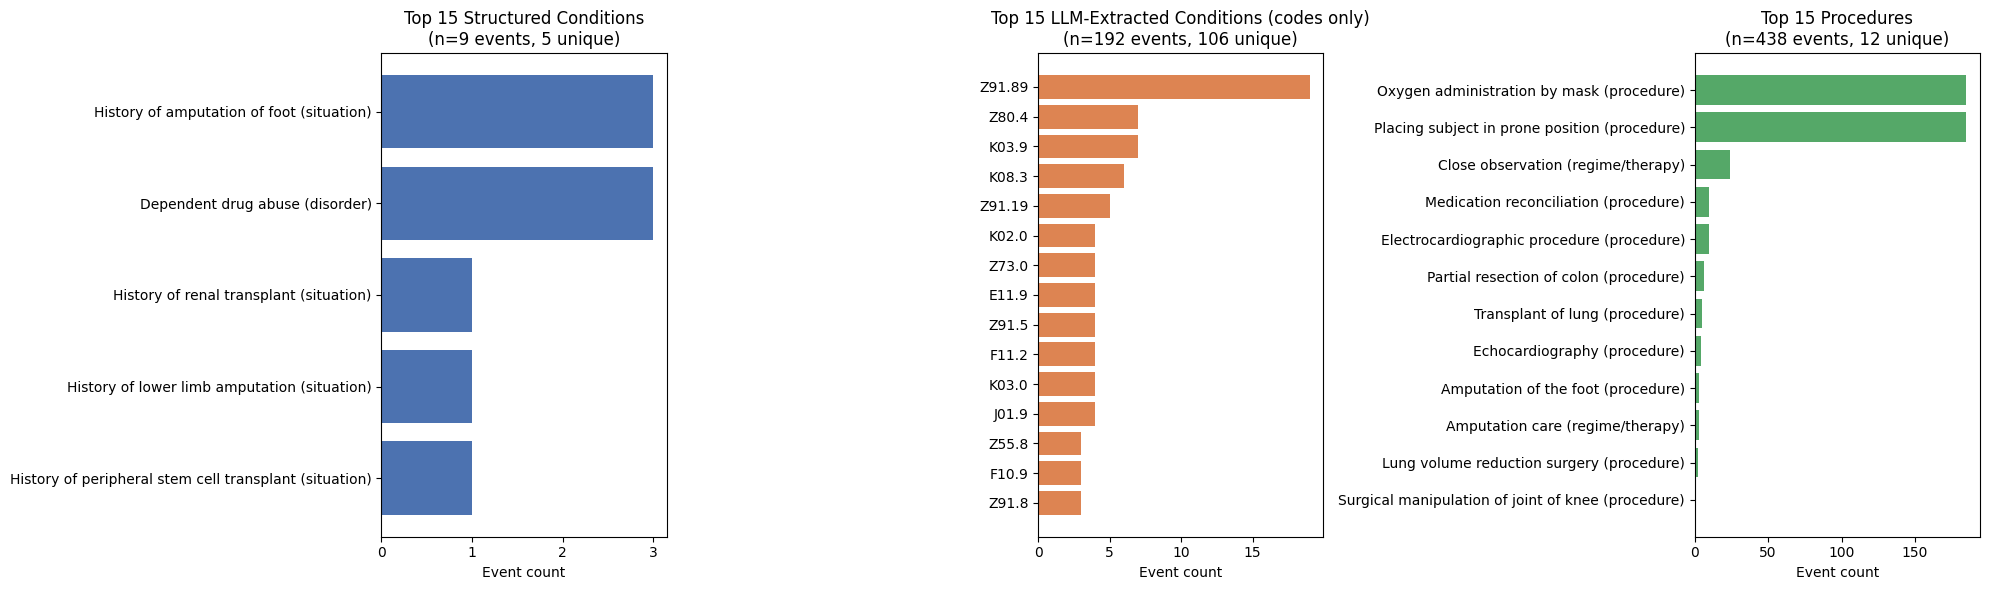

In [ ]:
# cell 24b — condition & procedure frequency bar charts (human-readable labels)
import matplotlib.pyplot as plt
import pandas as pd

TOP_N = 15

# ---------- 1. Structured conditions ----------
struct_cond_counts = cond_df['icd_code'].astype(str).value_counts().head(TOP_N)
struct_code_to_desc = (
    cond_df.assign(icd_code=lambda d: d['icd_code'].astype(str))
    .drop_duplicates('icd_code')
    .set_index('icd_code')['DESCRIPTION']
    .to_dict()
)
struct_labels = [struct_code_to_desc.get(c, c) for c in struct_cond_counts.index]

# ---------- 2. LLM-extracted conditions (no description available — codes only) ----------
llm_all_codes = [str(c) for codes in llm_icd_codes.values() for c in codes]
llm_cond_counts = pd.Series(llm_all_codes).value_counts().head(TOP_N)
llm_labels = list(llm_cond_counts.index)  # bare codes, no lookup — flagged separately

# ---------- 3. Procedures ----------
proc_counts = proc_df_mapped['icd10pcs_code'].astype(str).value_counts().head(TOP_N)
proc_code_to_desc = (
    proc_df_mapped.drop_duplicates('icd10pcs_code')
    .set_index('icd10pcs_code')['proc_description']
    .to_dict()
)
proc_labels = [proc_code_to_desc.get(c, c) for c in proc_counts.index]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].barh(struct_labels[::-1], struct_cond_counts.values[::-1], color='#4C72B0')
axes[0].set_title(f"Top {TOP_N} Structured Conditions\n(n={len(cond_df)} events, {cond_df['icd_code'].nunique()} unique)")
axes[0].set_xlabel("Event count")

axes[1].barh(llm_labels[::-1], llm_cond_counts.values[::-1], color='#DD8452')
axes[1].set_title(f"Top {TOP_N} LLM-Extracted Conditions (codes only)\n(n={len(llm_all_codes)} events, {len(set(llm_all_codes))} unique)")
axes[1].set_xlabel("Event count")

axes[2].barh(proc_labels[::-1], proc_counts.values[::-1], color='#55A868')
axes[2].set_title(f"Top {TOP_N} Procedures\n(n={len(proc_df_mapped)} events, {proc_df_mapped['icd10pcs_code'].nunique()} unique)")
axes[2].set_xlabel("Event count")

plt.tight_layout()
plt.savefig(f"{output_path}/frequency_charts_readable.png", dpi=300)
plt.show()

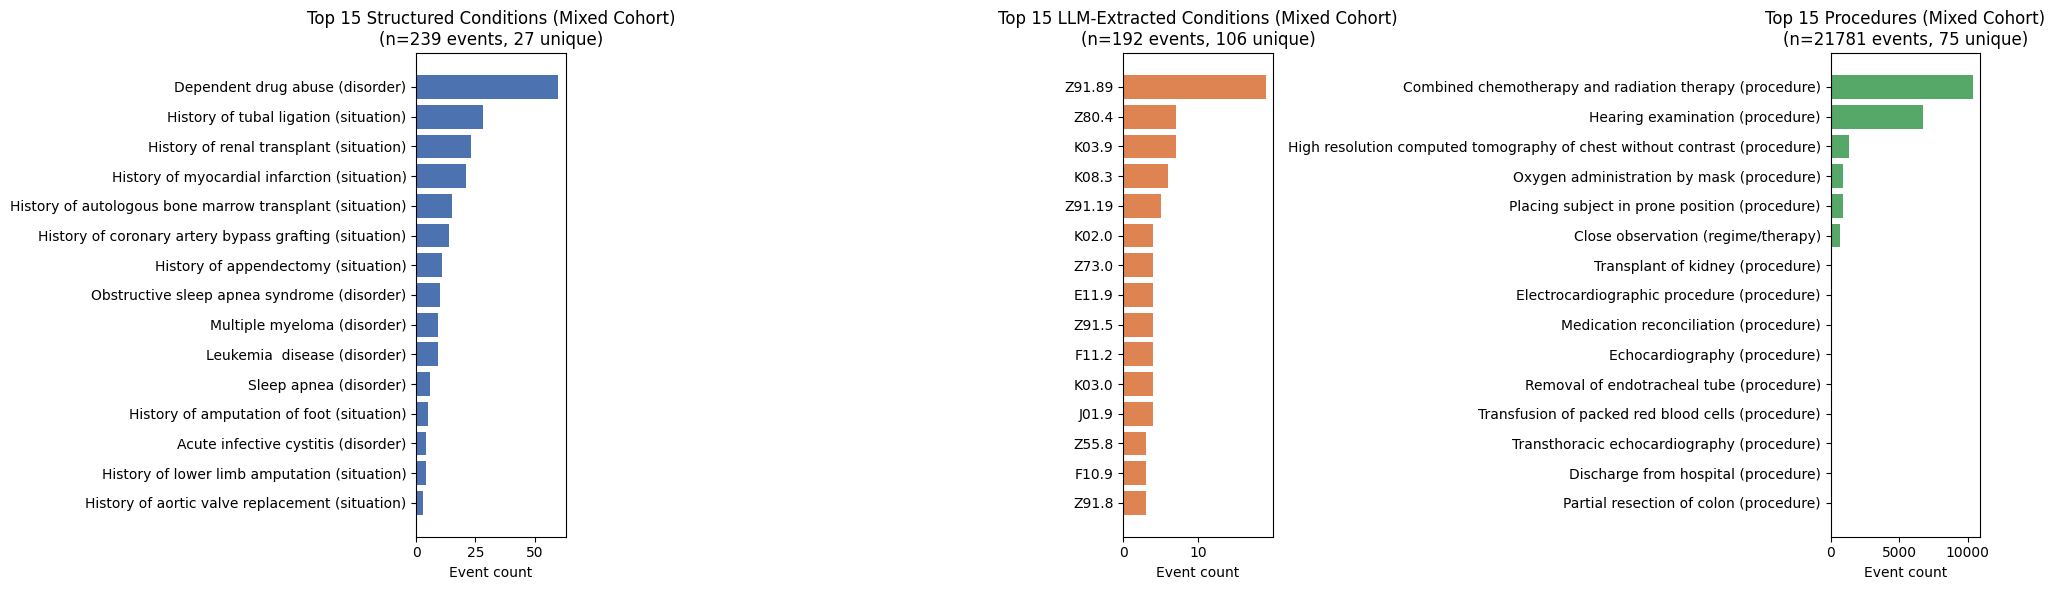

In [ ]:
# cell 24d — condition & procedure frequency bar charts, MIXED cohort
import matplotlib.pyplot as plt
import pandas as pd

TOP_N = 15

# ---------- 1. Structured conditions ----------
struct_cond_counts_mixed = cond_df_mixed['icd_code'].astype(str).value_counts().head(TOP_N)
struct_code_to_desc_mixed = (
    cond_df_mixed.assign(icd_code=lambda d: d['icd_code'].astype(str))
    .drop_duplicates('icd_code')
    .set_index('icd_code')['DESCRIPTION']
    .to_dict()
)
struct_labels_mixed = [struct_code_to_desc_mixed.get(c, c) for c in struct_cond_counts_mixed.index]

# ---------- 2. LLM-extracted conditions (codes only — no description source) ----------
# NOTE: confirm llm_icd_codes was built over mixed_cohort_hadm_ids before trusting this panel.
# If it was only run on the 37-encounter pure cohort, this will undercount badly, same failure
# mode as cond_df/proc_df did before the cohort mixup was caught.
llm_all_codes_mixed = [str(c) for hid, codes in llm_icd_codes.items()
                        if hid in mixed_cohort_hadm_ids for c in codes]
llm_cond_counts_mixed = pd.Series(llm_all_codes_mixed).value_counts().head(TOP_N)
llm_labels_mixed = list(llm_cond_counts_mixed.index)

# ---------- 3. Procedures ----------
proc_counts_mixed = proc_df_mapped_mixed['icd10pcs_code'].astype(str).value_counts().head(TOP_N)
proc_code_to_desc_mixed = (
    proc_df_mapped_mixed.drop_duplicates('icd10pcs_code')
    .set_index('icd10pcs_code')['proc_description']
    .to_dict()
)
proc_labels_mixed = [proc_code_to_desc_mixed.get(c, c) for c in proc_counts_mixed.index]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].barh(struct_labels_mixed[::-1], struct_cond_counts_mixed.values[::-1], color='#4C72B0')
axes[0].set_title(f"Top {TOP_N} Structured Conditions (Mixed Cohort)\n(n={len(cond_df_mixed)} events, {cond_df_mixed['icd_code'].nunique()} unique)")
axes[0].set_xlabel("Event count")

axes[1].barh(llm_labels_mixed[::-1], llm_cond_counts_mixed.values[::-1], color='#DD8452')
axes[1].set_title(f"Top {TOP_N} LLM-Extracted Conditions (Mixed Cohort)\n(n={len(llm_all_codes_mixed)} events, {len(set(llm_all_codes_mixed))} unique)")
axes[1].set_xlabel("Event count")

axes[2].barh(proc_labels_mixed[::-1], proc_counts_mixed.values[::-1], color='#55A868')
axes[2].set_title(f"Top {TOP_N} Procedures (Mixed Cohort)\n(n={len(proc_df_mapped_mixed)} events, {proc_df_mapped_mixed['icd10pcs_code'].nunique()} unique)")
axes[2].set_xlabel("Event count")

plt.tight_layout()
plt.savefig(f"{output_path}/frequency_charts_mixed.png", dpi=300)
plt.show()

In [ ]:
print(f"Total encounters with LLM extraction results: {len(llm_icd_codes)}")
print(f"Overlaps with pure cohort ({len(cohort_hadm_ids)} encounters): {len(set(llm_icd_codes.keys()) & cohort_hadm_ids)}")
print(f"Overlaps with mixed cohort ({len(mixed_cohort_hadm_ids)} encounters): {len(set(llm_icd_codes.keys()) & mixed_cohort_hadm_ids)}")

Total encounters with LLM extraction results: 364
Overlaps with pure cohort (37 encounters): 37
Overlaps with mixed cohort (2578 encounters): 364


In [ ]:
print(f"llm_icd_codes entries: {len(llm_icd_codes)}")
print(f"Overlaps mixed cohort: {len(set(llm_icd_codes.keys()) & mixed_cohort_hadm_ids)}")

llm_icd_codes entries: 364
Overlaps mixed cohort: 364


In [ ]:
with open(f"{matrices_dir}/encounter_notes.pkl", 'rb') as f:
    encounter_notes = pickle.load(f)

print(type(encounter_notes), len(encounter_notes))
k = next(iter(encounter_notes))
print(repr(k), '->', repr(encounter_notes[k])[:300])

<class 'dict'> 37
'05a10115-281a-d838-2e5f-0486075891e1' -> '1995-09-21\n\n# Chief Complaint\n- Hunger\n\n\n# History of Present Illness\nGrant908 is a 45 year-old nonhispanic white male. Patient has a history of limited social contact (finding).\n\n# Social History\nPatient is married. Patient quit smoking at age 17.\n Patient identifies as heterosexual.\n\


In [ ]:
# rebuild encounter_notes for the MIXED cohort (2,578 encounters)
notes_dir = "/content/drive/MyDrive/RAIM_Project_v2/run_05_age_med_years_med/raw/notes"
note_files = os.listdir(notes_dir)
subject_to_notefile = {}
for fname in note_files:
    uuid = fname.replace('.txt', '').split('_')[-1]
    subject_to_notefile[uuid] = os.path.join(notes_dir, fname)

DATE_PATTERN = re.compile(r'^\d{4}-\d{2}-\d{2}', re.MULTILINE)

def parse_note_sections(note_text):
    matches = list(DATE_PATTERN.finditer(note_text))
    sections = []
    for i, match in enumerate(matches):
        date_str = match.group()
        start = match.start()
        end = matches[i+1].start() if i+1 < len(matches) else len(note_text)
        chunk = note_text[start:end].strip()
        try:
            date = datetime.strptime(date_str, '%Y-%m-%d')
            sections.append((date, chunk))
        except:
            continue
    return sections

def assign_sections_for_patient(sections, encounters, tolerance_days=3):
    candidates = []
    for e_idx, (hadm_id, admittime) in enumerate(encounters):
        admit_dt = pd.Timestamp(admittime).to_pydatetime().replace(tzinfo=None)
        for s_idx, (sec_date, sec_text) in enumerate(sections):
            delta = abs(sec_date - admit_dt)
            if delta <= timedelta(days=tolerance_days):
                candidates.append((delta, e_idx, s_idx))
    candidates.sort(key=lambda x: x[0])
    used_section_idxs, assigned_encounters, assignments = set(), set(), {}
    for delta, e_idx, s_idx in candidates:
        if e_idx in assigned_encounters or s_idx in used_section_idxs:
            continue
        assignments[encounters[e_idx][0]] = sections[s_idx][1]
        used_section_idxs.add(s_idx)
        assigned_encounters.add(e_idx)
    return assignments

encounter_notes_mixed = {}
missing_file = 0
no_match = 0

for subject_id, group in mixed_df.groupby('subject_id'):
    uuid = subject_id
    if uuid not in subject_to_notefile:
        missing_file += len(group)
        continue
    with open(subject_to_notefile[uuid], 'r', encoding='utf-8', errors='ignore') as f:
        note_text = f.read()
    sections = parse_note_sections(note_text)
    encounters = list(zip(group['hadm_id'], group['admittime']))
    assignments = assign_sections_for_patient(sections, encounters)
    for hadm_id, text in assignments.items():
        encounter_notes_mixed[hadm_id] = text
    no_match += len(encounters) - len(assignments)

print(f"Encounter notes extracted: {len(encounter_notes_mixed)} / {len(mixed_df)}")
print(f"Missing note file: {missing_file}")
print(f"No matching section found: {no_match}")

with open(f"{matrices_dir}/encounter_notes_mixed.pkl", 'wb') as f:
    pickle.dump(encounter_notes_mixed, f)

Encounter notes extracted: 2578 / 2578
Missing note file: 0
No matching section found: 0


In [ ]:
# cell 24d — condition & procedure frequency bar charts, MIXED cohort
import matplotlib.pyplot as plt
import pandas as pd

TOP_N = 15

# ---------- 1. Structured conditions ----------
struct_cond_counts_mixed = cond_df_mixed['icd_code'].astype(str).value_counts().head(TOP_N)
struct_code_to_desc_mixed = (
    cond_df_mixed.assign(icd_code=lambda d: d['icd_code'].astype(str))
    .drop_duplicates('icd_code')
    .set_index('icd_code')['DESCRIPTION']
    .to_dict()
)
struct_labels_mixed = [struct_code_to_desc_mixed.get(c, c) for c in struct_cond_counts_mixed.index]

# ---------- 2. LLM-extracted conditions (codes only — no description source) ----------
llm_all_codes_mixed = [str(c) for hid, codes in llm_icd_codes_mixed.items()
                        if hid in mixed_cohort_hadm_ids for c in codes]
llm_cond_counts_mixed = pd.Series(llm_all_codes_mixed).value_counts().head(TOP_N)
llm_labels_mixed = list(llm_cond_counts_mixed.index)

# ---------- 3. Procedures ----------
proc_counts_mixed = proc_df_mapped_mixed['icd10pcs_code'].astype(str).value_counts().head(TOP_N)
proc_code_to_desc_mixed = (
    proc_df_mapped_mixed.drop_duplicates('icd10pcs_code')
    .set_index('icd10pcs_code')['proc_description']
    .to_dict()
)
proc_labels_mixed = [proc_code_to_desc_mixed.get(c, c) for c in proc_counts_mixed.index]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].barh(struct_labels_mixed[::-1], struct_cond_counts_mixed.values[::-1], color='#4C72B0')
axes[0].set_title(f"Top {TOP_N} Structured Conditions (Mixed Cohort)\n(n={len(cond_df_mixed)} events, {cond_df_mixed['icd_code'].nunique()} unique)")
axes[0].set_xlabel("Event count")

axes[1].barh(llm_labels_mixed[::-1], llm_cond_counts_mixed.values[::-1], color='#DD8452')
axes[1].set_title(f"Top {TOP_N} LLM-Extracted Conditions (Mixed Cohort)\n(n={len(llm_all_codes_mixed)} events, {len(set(llm_all_codes_mixed))} unique)")
axes[1].set_xlabel("Event count")

axes[2].barh(proc_labels_mixed[::-1], proc_counts_mixed.values[::-1], color='#55A868')
axes[2].set_title(f"Top {TOP_N} Procedures (Mixed Cohort)\n(n={len(proc_df_mapped_mixed)} events, {proc_df_mapped_mixed['icd10pcs_code'].nunique()} unique)")
axes[2].set_xlabel("Event count")

plt.savefig(f"{output_path}/frequency_charts_mixed.png", dpi=300)
plt.show()

NameError: name 'llm_icd_codes_mixed' is not defined